In [1]:
import sys, os, importlib
package_path = os.path.abspath('../../')
if package_path not in sys.path:
    sys.path.append(package_path)
from package import functions as fn
from package import model as rm
from package import optimizer as opt
from package import plots
import numpy as np
import pandas as pd
import nbformat as nbf
from obspy.taup import TauPyModel
from obspy.geodetics import gps2dist_azimuth
from obspy.geodetics import kilometers2degrees
from obspy import read
from obspy import Stream
from matplotlib import pyplot as plt

from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

np.set_printoptions(precision=4, suppress=True)
for module in [fn, rm, opt, plots]:
    importlib.reload(module)

# set seed for reproducibility
np.random.seed(2026)

In [2]:
np.sqrt(36**2 - 35**2)

8.426149773176359

#### SOURCE MECHANISM

Original params:  [190  30   9]


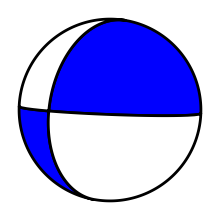

In [19]:
np.random.seed(2025)

# get true params for synthetic test
benchmark = (np.array([190, 30, 9]), np.array([91, 85, 120]))
true_params = benchmark[0]
print('Original params: ', true_params)

# plot corresponding beachball
beachball = fn.beachball(true_params)

# velocity model, assume depth, vp and vs cols
velocity_model = TauPyModel(model='ak135')
data_path = '../../data/AK135_lookup.csv'
lookup_table = pd.read_csv(data_path)

In [20]:
# 26.8513° S	63.2373° W
eq_lat = 18.820333
eq_lon = -155.527167
hdepth = 35.06  # depth in km

In [21]:
'''
ANMO, COR

PAB
Earthquake coordinates: lat -26.8513, lon -63.2373
Station coordinates: lat 39.54, lon -4.35
Distance between event and station: 9554.96 km, 85.93 degrees
Azimuth: 41.59, Back-azimuth: 230.13
Original azimuth: 41.58, back-azimuth: 230.07

SLBS
Earthquake coordinates: lat -26.8513, lon -63.2373
Station coordinates: lat 23.69, lon -109.94
Distance between event and station: 7516.04 km, 67.59 degrees
Azimuth: 313.75, Back-azimuth: 135.26
Original azimuth: 313.77, back-azimuth: 135.28
'''

'\nANMO, COR\n\nPAB\nEarthquake coordinates: lat -26.8513, lon -63.2373\nStation coordinates: lat 39.54, lon -4.35\nDistance between event and station: 9554.96 km, 85.93 degrees\nAzimuth: 41.59, Back-azimuth: 230.13\nOriginal azimuth: 41.58, back-azimuth: 230.07\n\nSLBS\nEarthquake coordinates: lat -26.8513, lon -63.2373\nStation coordinates: lat 23.69, lon -109.94\nDistance between event and station: 7516.04 km, 67.59 degrees\nAzimuth: 313.75, Back-azimuth: 135.26\nOriginal azimuth: 313.77, back-azimuth: 135.28\n'

In [22]:
velocity_model = TauPyModel(model='ak135')
vel_model_path = '../../data/AK135_lookup.csv'
lookup_table = pd.read_csv(vel_model_path)

alpha, beta = fn.extract_velocities(lookup_table, hdepth)
print(f'At depth {hdepth} km, P velocity = {alpha} km/s, S velocity = {beta} km/s')

At depth 35.06 km, P velocity = 8.040007058823528 km/s, S velocity = 4.480014117647059 km/s


#### STATION LOCAION 1

In [23]:
# set up hyperparameters for inversion
epdist_1 = 59.37  # degrees - epicentral distance
azimuth_1 = 46.18  # degrees - azimuth of seismometer

p_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                        distance_in_degree=epdist_1, phase_list=['P'])
s_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                        distance_in_degree=epdist_1, phase_list=['S'])
takeoff_angles = [p_arrivals[0].takeoff_angle, s_arrivals[0].takeoff_angle]
velocities = fn.extract_velocities(lookup_table, hdepth)

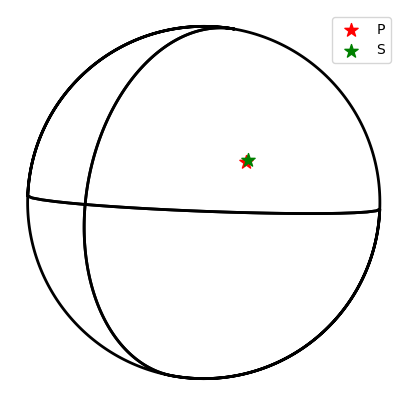

In [24]:
fig, ax = plt.subplots(figsize=(5,5))

# Example moment tensor
t, p = fn.sdr2tp(true_params, deg=True)
enu_mt = fn.tp2mt(t, p)
mt = fn.enu2use(enu_mt)
comp_mt = np.array([
                mt[0,0], mt[1,1], mt[2,2],
                mt[0,1], mt[0,2], mt[1,2],
            ])

b = fn.beach(comp_mt, facecolor='b', bgcolor='w', edgecolor='k', nofill=True)
ax.add_collection(b)

# escape point coordinates
# toff_mean = np.mean(takeoff_angles)
az = azimuth_1
r1 = 100 * takeoff_angles[0]/90
r2 = 100 * takeoff_angles[1]/90
x1 = r1 * np.sin(np.deg2rad(az))
y1 = r1 * np.cos(np.deg2rad(az))
x2 = r2 * np.sin(np.deg2rad(az))
y2 = r2 * np.cos(np.deg2rad(az))

ax.scatter(x1, y1, color='red', s=100, marker='*', label='P')
ax.scatter(x2, y2, color='green', s=100, marker='*', label='S')
ax.legend(loc='upper right')

# hide axes
ax.set_axis_off()

plt.axis('equal')
plt.show()

In [25]:
# initialize model
radiation_model_1 = rm.RadiationModel(np.deg2rad(azimuth_1), takeoff_angles, velocities)

model_Ao1 = radiation_model_1(np.deg2rad(true_params), set_Ao=True, return_A=True)

# tune hyperparameters for optimization
config = opt.get_config()
config['k_max'] = 4000

# multistart optimization
num_starts = 50
starts = fn.random_params(num_starts)

radiation_model_1.reset()
print_every = 10

for index, start in enumerate(starts):
    if print_every > 0 and index % print_every == 0:
        print(f'Run {index} of {num_starts}')
    opt.minimize(radiation_model_1, config, start)

print(f'Convergence rate: {radiation_model_1.get_convergence_rate():.0f}%')


Using sdr parameters.
Run 0 of 50


Run 10 of 50
Run 20 of 50
Run 30 of 50
Run 40 of 50
Convergence rate: 90%


In [26]:
fn.unit_vec(model_Ao1)

array([ 0.2134, -0.6748, -0.7064])

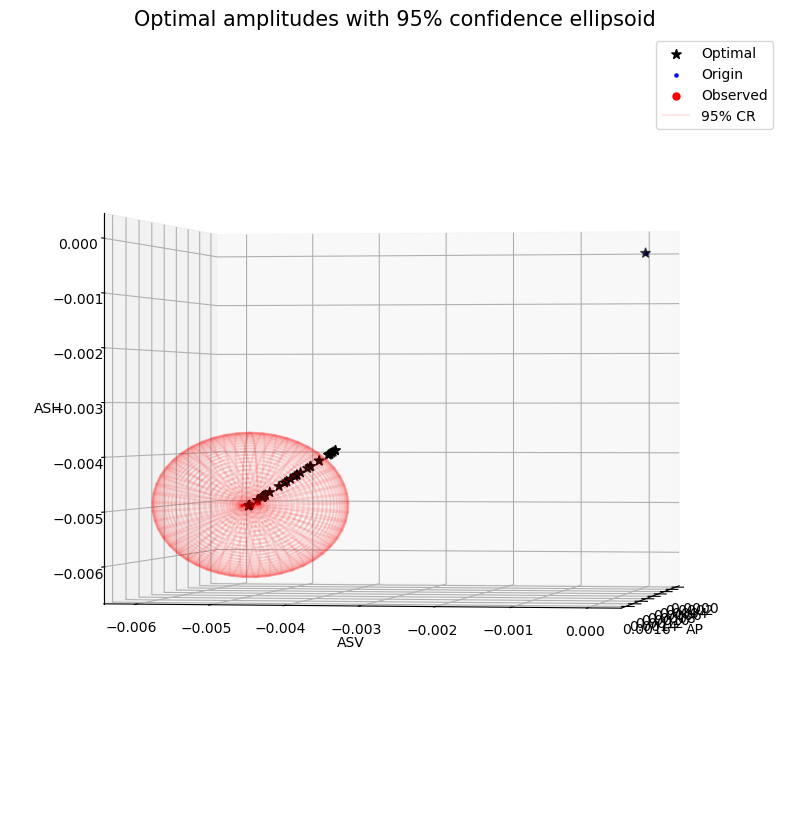

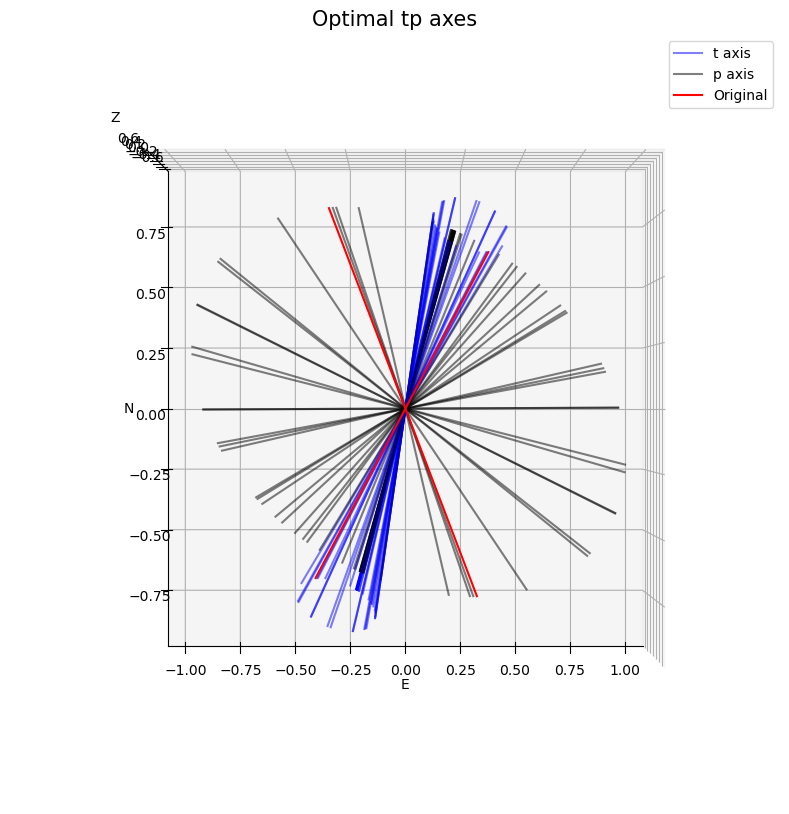

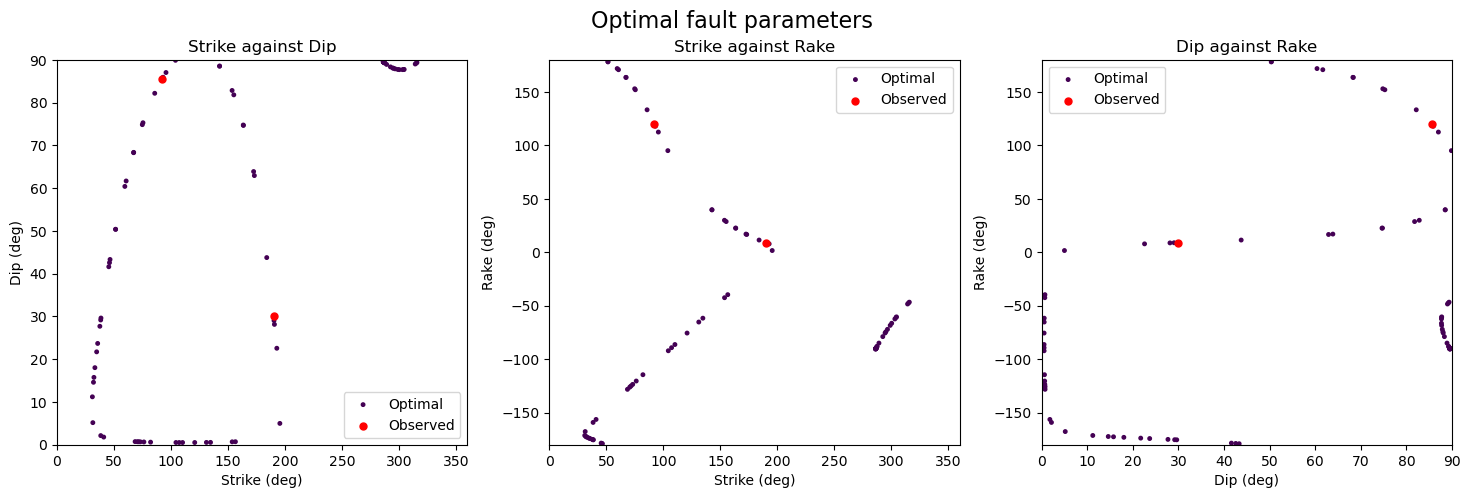

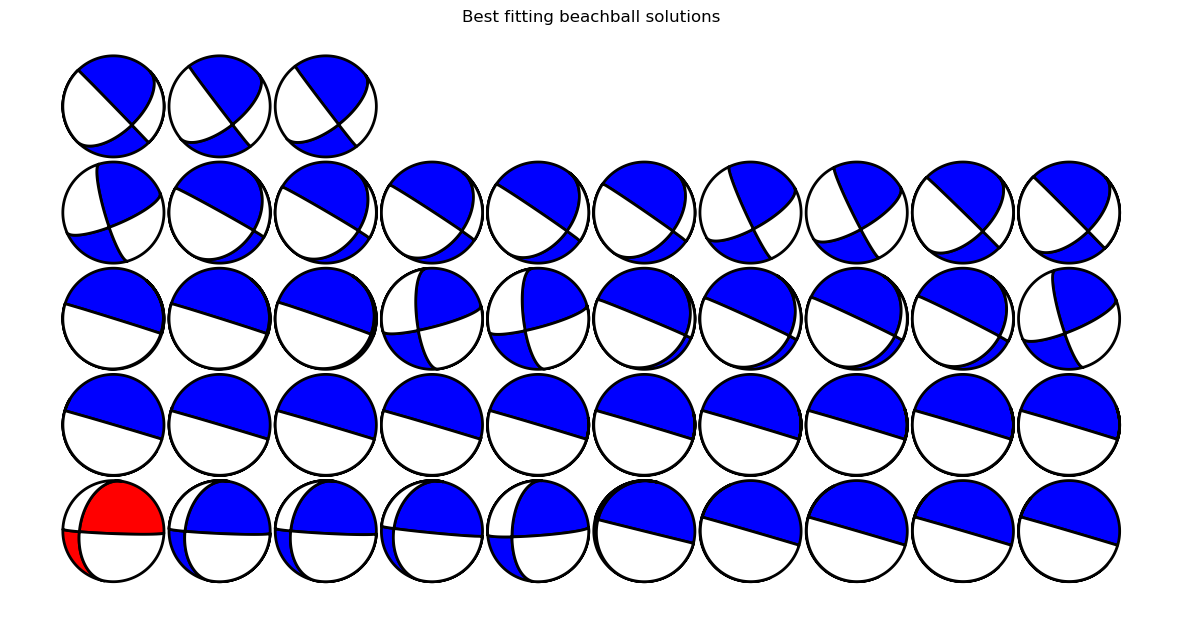

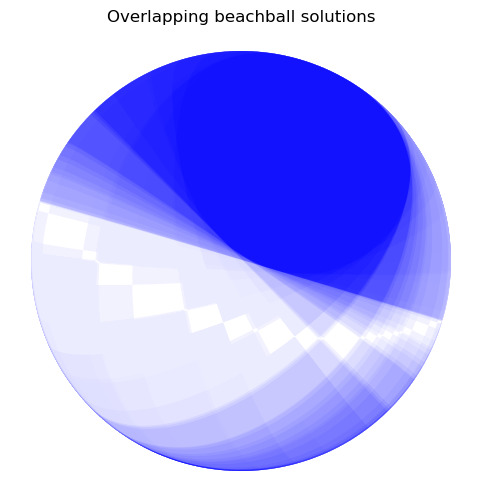

In [27]:
# amplitude plot
radiation_model_1.reset_grid_amplitudes()
radiation_model_1.set_grid_amplitudes(7, random=False, fix_params=False)
plots.amplitudes(radiation_model_1, azim=10, elev=0, s=50, alpha=0.5,
                 iterates=False, grid=False, cross_section=[0,0,0],
                 eps_factor=2e-2, optimal=True, observed=True, cmap='rainbow',
                    uncertainty=True, conf=0.95)

# tp axis plot
plots.tp_axes(radiation_model_1, azim=-90, elev=90, half=False)

# 2D iterates plot
plots.iterates_2D(radiation_model_1, s=25, optimal=True, index=2, cmap='viridis')
# plots.iterates_2D(radiation_model_1, s=25, optimal=True, index=2, cmap='viridis',
#                     uncertainty=True, conf=0.95)

# beachball plots
plots.beachballs(radiation_model_1, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(15,10), overlap=False, original=True)
# plots.beachballs(radiation_model_1, order_by='kagan', width=10,  max_plot=50,
#                  original=True, figsize=(15,10), overlap=False, uncertainty=True)

# overlapping beachball plot
plots.beachballs(radiation_model_1, order_by='strike', width=10,  max_plot=50,
                 facecolor='blue', figsize=(6,6), overlap=True, original=True)

In [28]:
# Distance between event and station: 7516.04 km, 67.59 degrees
# Azimuth: 313.75, Back-azimuth: 135.26
# Original azimuth: 313.77, back-azimuth: 135.28

In [29]:
# Earthquake coordinates: lat 18.820333, lon -155.527167
# Station coordinates: lat 44.59, lon -123.30
# Distance between event and station: 4133.01 km, 37.17 degrees
# Azimuth: 39.07, Back-azimuth: 236.77
# Original azimuth: 39.10, back-azimuth: 236.72

#### STATION LOCAION 2

In [30]:
# set up hyperparameters for inversion
epdist_2 = 37.17  # degrees - epicentral distance
azimuth_2 = 39.10  # degrees - azimuth of seismometer

p_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                        distance_in_degree=epdist_2, phase_list=['P'])
s_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                        distance_in_degree=epdist_2, phase_list=['S'])
takeoff_angles = [p_arrivals[0].takeoff_angle, s_arrivals[0].takeoff_angle]
velocities = fn.extract_velocities(lookup_table, hdepth)

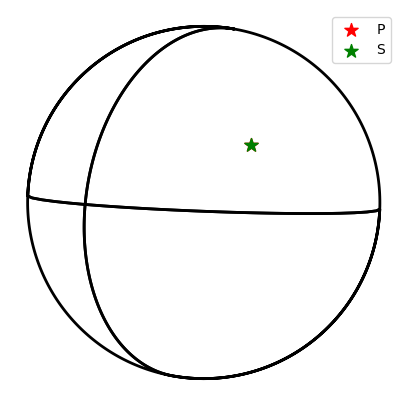

In [31]:
fig, ax = plt.subplots(figsize=(5,5))

# Example moment tensor
t, p = fn.sdr2tp(true_params, deg=True)
enu_mt = fn.tp2mt(t, p)
mt = fn.enu2use(enu_mt)
comp_mt = np.array([
                mt[0,0], mt[1,1], mt[2,2],
                mt[0,1], mt[0,2], mt[1,2],
            ])

b = fn.beach(comp_mt, facecolor='b', bgcolor='w', edgecolor='k', nofill=True)
ax.add_collection(b)

# escape point coordinates
# toff_mean = np.mean(takeoff_angles)
az = azimuth_2
r1 = 100 * takeoff_angles[0]/90
r2 = 100 * takeoff_angles[1]/90
x1 = r1 * np.sin(np.deg2rad(az))
y1 = r1 * np.cos(np.deg2rad(az))
x2 = r2 * np.sin(np.deg2rad(az))
y2 = r2 * np.cos(np.deg2rad(az))

ax.scatter(x1, y1, color='red', s=100, marker='*', label='P')
ax.scatter(x2, y2, color='green', s=100, marker='*', label='S')
ax.legend(loc='upper right')

# hide axes
ax.set_axis_off()

plt.axis('equal')
plt.show()

In [32]:

# initialize model
radiation_model_2 = rm.RadiationModel(np.deg2rad(azimuth_2), takeoff_angles, velocities)

model_Ao2 = radiation_model_2(np.deg2rad(true_params), set_Ao=True, return_A=True)

# tune hyperparameters for optimization
config = opt.get_config()
config['k_max'] = 4000

# multistart optimization
num_starts = 50
starts = fn.random_params(num_starts)

radiation_model_2.reset()
print_every = 10

for index, start in enumerate(starts):
    if print_every > 0 and index % print_every == 0:
        print(f'Run {index} of {num_starts}')
    opt.minimize(radiation_model_2, config, start)

print(f'Convergence rate: {radiation_model_2.get_convergence_rate():.0f}%')


Using sdr parameters.
Run 0 of 50
Run 10 of 50
Run 20 of 50
Run 30 of 50
Run 40 of 50
Convergence rate: 86%


In [33]:
fn.unit_vec(model_Ao2)

array([ 0.3782, -0.6966, -0.6097])

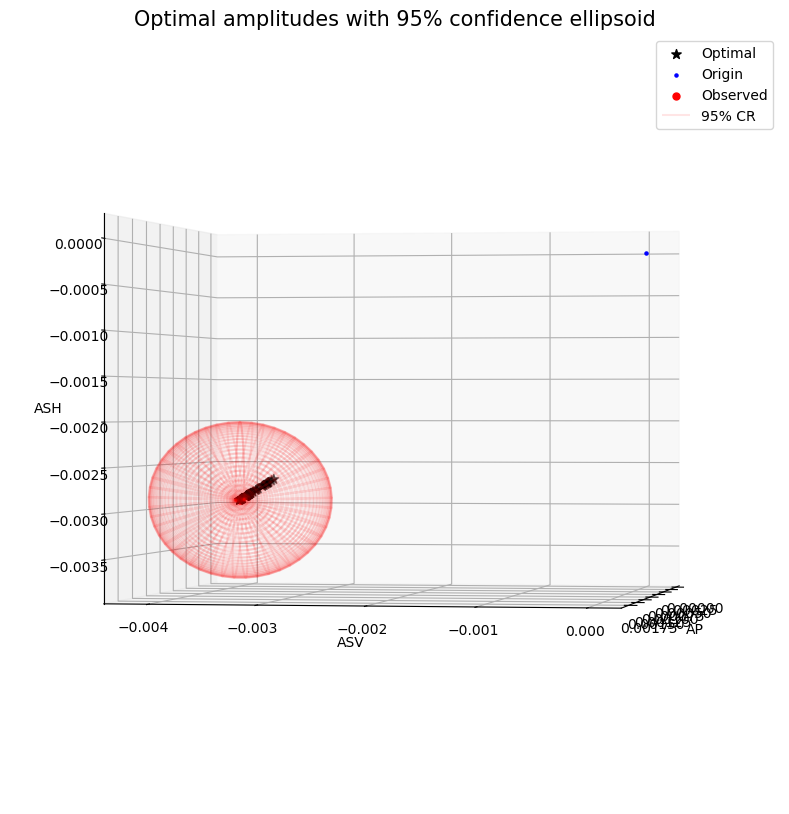

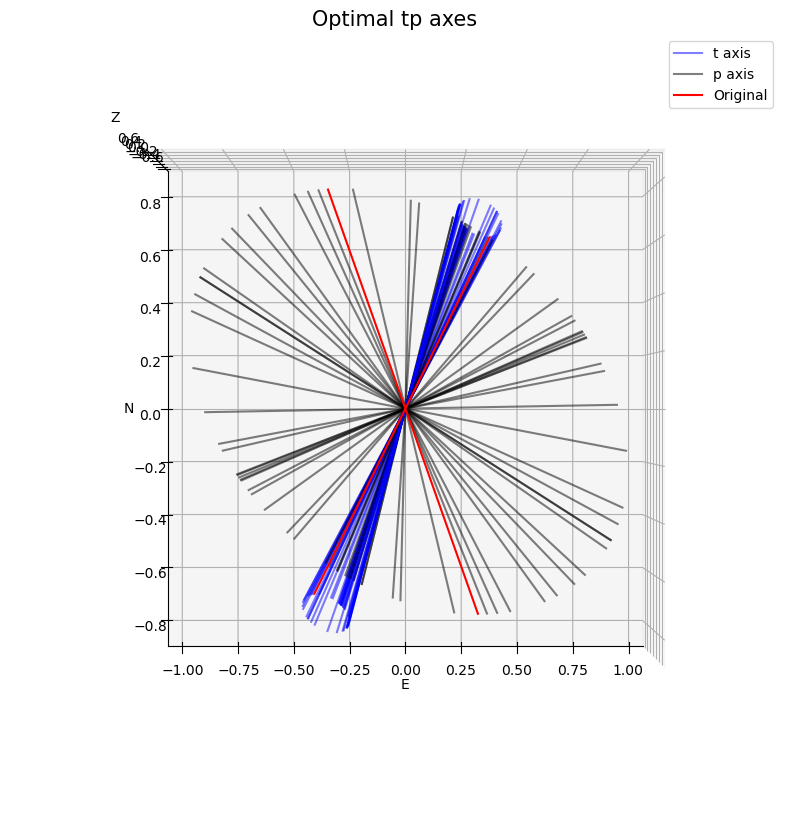

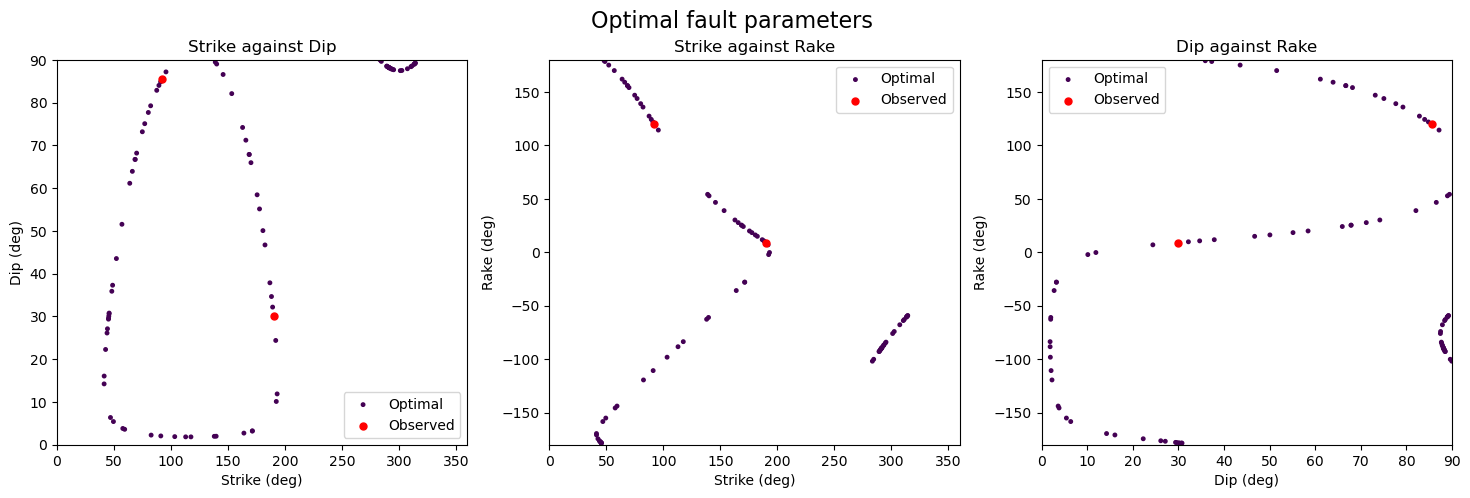

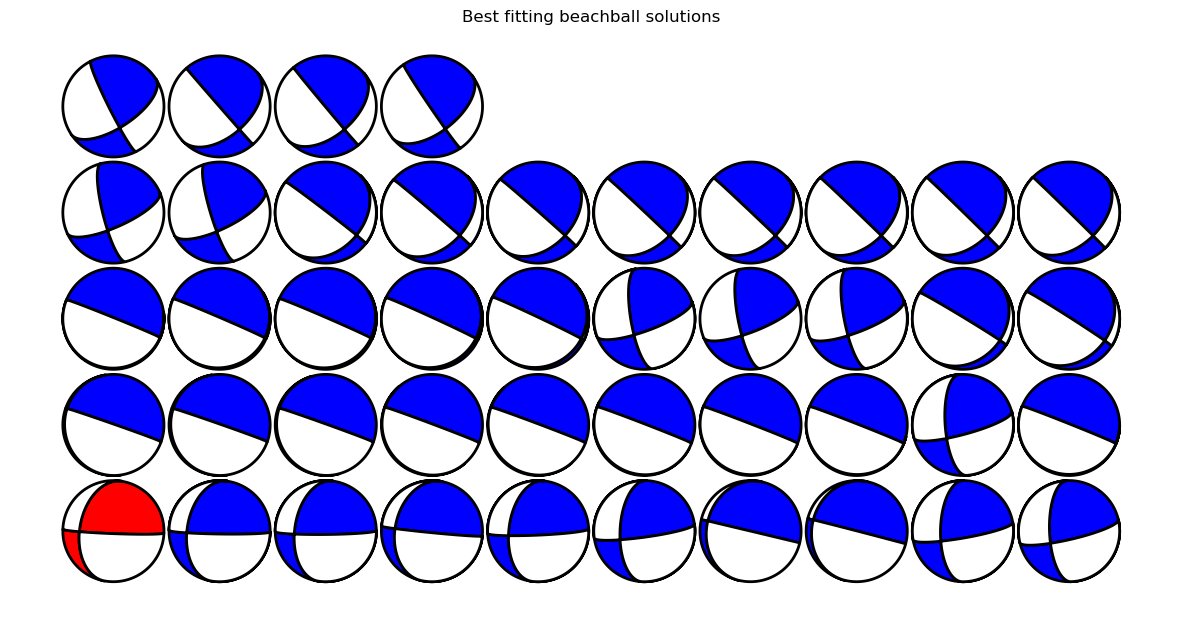

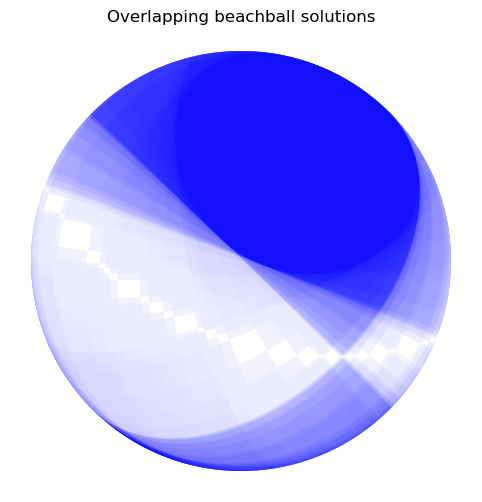

In [34]:
# amplitude plot
radiation_model_2.reset_grid_amplitudes()
radiation_model_2.set_grid_amplitudes(7, random=False, fix_params=False)
plots.amplitudes(radiation_model_2, azim=10, elev=0, s=50, alpha=0.5,
                 iterates=False, grid=False, cross_section=[0,0,0],
                 eps_factor=2e-2, optimal=True, observed=True, cmap='rainbow',
                    uncertainty=True, conf=0.95)

# tp axis plot
plots.tp_axes(radiation_model_2, azim=-90, elev=90, half=False)

# 2D iterates plot
plots.iterates_2D(radiation_model_2, s=25, optimal=True, index=2, cmap='viridis')
# plots.iterates_2D(radiation_model_2, s=25, optimal=True, index=2, cmap='viridis',
#                     uncertainty=True, conf=0.95)

# beachball plots
plots.beachballs(radiation_model_2, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(15,10), overlap=False, original=True)
# plots.beachballs(radiation_model_2, order_by='kagan', width=10,  max_plot=50,
#                  original=True, figsize=(15,10), overlap=False, uncertainty=True)

# overlapping beachball plot
plots.beachballs(radiation_model_2, order_by='strike', width=10,  max_plot=50,
                 facecolor='blue', figsize=(6,6), overlap=True, original=True)